In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gsw
import xarray as xr
import utils
import os
from scipy.spatial import Delaunay
import time as tm
from scipy.sparse import *
from scipy.ndimage.filters import gaussian_filter
from scipy.sparse.linalg import spsolve

/tmp/ipykernel_40010/3418746898.py:10: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


### Model dimensions

In [2]:
Lx,Ly=200e3,200e3 #good for eddy size R=10e3

dx=500 #in meters #LR : 2e3
dy=500
ngrid_z = 100

ngrid_x = int(Lx/dx)
ngrid_y = int(Ly/dy)


#Dimensions of box channel
Lx=ngrid_x*dx
Ly=ngrid_y*dy
Lz=4000#m

print(ngrid_x,ngrid_y)

# Array of dims of simulation
# Center points
x=np.linspace(dx/2, Lx-dx/2, ngrid_x)
y=np.linspace(dy/2, Ly-dy/2, ngrid_y)

# Edge grid
xu=np.linspace(0, Lx, ngrid_x + 1)
yv=np.linspace(0, Ly, ngrid_y + 1)

# xx,yy=np.meshgrid(x, y)

#Build initial conditions in edge conditions and then before storing interpolate to the center grid
xx,yy=np.meshgrid(xu, yv)

lat=80

400 400


## Depth definition:

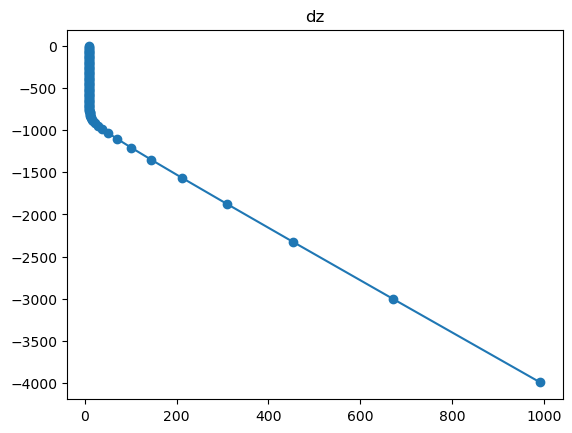

In [3]:
refinement = 4 # controls spacing near surface (higher means finer spaced)
stretching = 40  # controls rate of stretching at bottom

k=np.arange(1,ngrid_z+1)
# Normalized height ranging from 0 to 1
h = (k - 1) / ngrid_z

# Linear near-surface generator
eta = 1 + (h - 1) / refinement

# Bottom-intensified stretching function
Σ = (1 - np.exp(-stretching * h) / (1 - np.exp(-stretching)))

# Generating function
z_faces = Lz * (eta * Σ - 1)

#Flip for consistency with python code
z_faces = np.flipud(-z_faces)

depth = z_faces

plt.title('dz')
plt.plot(np.diff(z_faces),-np.cumsum(np.diff(z_faces)),'o-')
plt.show()

# Background profiles

## First load profiles from CREG12

In [4]:
temp_prof = xr.open_dataset("temperature_profile.nc")
salt_prof = xr.open_dataset("salinity_profile.nc")

In [5]:
temp_prof["deptht"]=-temp_prof["deptht"]
salt_prof["deptht"]=-salt_prof["deptht"]

Text(0.5, 0, 'Salt [psu]')

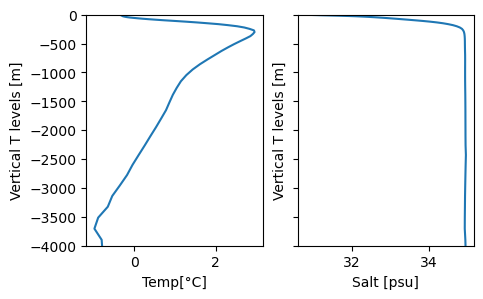

In [6]:
fig,ax = plt.subplots(1,2,figsize=(5,3),sharey=True)
temp_prof.temp.plot(y="deptht",ax=ax[0])
salt_prof.salt.plot(y="deptht",ax=ax[1])
ax[0].set_ylim(-4000,0)
# ax[0].invert_yaxis()
ax[0].set_xlabel("Temp[°C]")
ax[1].set_xlabel("Salt [psu]")

In [7]:
# Create salt and temperature profiles.
depth_salt_var = -np.tanh( ((z_faces)/ 750 ) * 2*np.pi ) +1 ;

def normalize(data):
    shift = data + abs(data.min())
    return shift/shift.max()

tanh_profile = normalize( np.tanh( (( z_faces - 150 )/ 500 ) * 2*np.pi )) - 0.4  * 3*np.tanh((z_faces-150)/2000)  * normalize( np.tanh( (( z_faces-450 )/ 1000 ) * 2 * np.pi ))

depth_temp_var = tanh_profile

S = 34.9
ΔS = 3.4 #ups 

init_sal_s = S - ΔS * depth_salt_var

ft_s= gsw.t_freezing(init_sal_s[0] ,0,0)

ΔT = 3.3
T0 = 1.5

init_temp_s = T0 + ft_s + ΔT * depth_temp_var #*np.ones_like(init_sal_s)

init_rho_s = gsw.rho(init_sal_s,init_temp_s,gsw.p_from_z(-np.array(z_faces),lat))
rho0=np.nanmean(init_rho_s)


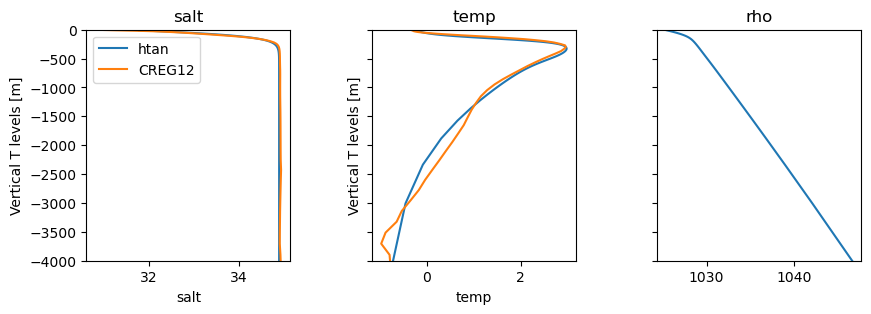

In [8]:
fig, ax = plt.subplots(1,3,figsize=(10,3),sharey=True)
ax[0].plot(init_sal_s,-z_faces,label='htan')
salt_prof.salt.plot(y="deptht",ax=ax[0],label='CREG12')
ax[0].set_title('salt')
ax[1].plot(init_temp_s,-z_faces,label='htan')
temp_prof.temp.plot(y="deptht",ax=ax[1],label='CREG12')
ax[1].set_title('temp')
ax[2].plot(init_rho_s,-z_faces,label='htan')
ax[2].set_title('rho')
plt.subplots_adjust(wspace=0.4)
ax[0].set_ylim(-4000,0)
ax[0].legend()